# Premier League Exploratory Data Analysis

This notebook contains exploratory data analysis results and visuals.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Data Analysis

In [2]:
PROCESSED_CSV = "../data/processed/epl_matches.csv"
matches = pd.read_csv(PROCESSED_CSV, parse_dates = ["Date"])
matches.head()

,Season,Date,HomeTeamID,AwayTeamID,HomeTeam,AwayTeam,HomeGoals,AwayGoals,Result
0,15-16,2015-08-08,2,1,Bournemouth,Aston Villa,0,1,A
1,15-16,2015-08-08,7,25,Chelsea,Swansea,2,2,D
2,15-16,2015-08-08,9,27,Everton,Watford,2,2,D
3,15-16,2015-08-08,14,24,Leicester,Sunderland,4,2,H
4,15-16,2015-08-08,17,26,Man United,Tottenham,1,0,H


We expect there to be $3420$ rows (from $9$ seasons of matches (2015-2016 through 2023-2024) with $380$ matches per season).

In [3]:
matches.shape

(3420, 9)

Because we have preprocessed the data already, we expect to have no null values.

Teams present in seasons used for model evaluation but not in seasons used for model training have a team ID of $-1$.

In [4]:
matches.isna().sum()

Season        0
Date          0
HomeTeamID    0
AwayTeamID    0
HomeTeam      0
AwayTeam      0
HomeGoals     0
AwayGoals     0
Result        0
dtype: int64

Below is the distribution of match outcomes:

In [5]:
matches["Result"].value_counts(normalize = True)

Result
H    0.449123
A    0.319006
D    0.231871
Name: proportion, dtype: float64

Below is a quick statistical summary of home goals and away goals in the Premier League.

On average, the home team scores ~1.56 goals per match and the away team scores ~1.26 goals per match. That is, football (soccer) is biased towards the home team.

In [6]:
matches[["HomeGoals", "AwayGoals"]].describe()

,HomeGoals,AwayGoals
count,3420.000000,3420.000000
mean,1.556140,1.262281
std,1.326516,1.215303
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,9.000000


Note that the distribution over goals for the home team and the away team roughly follows the Poisson distribution:

In [7]:
def poisson_counts(average, ks, n):
    """
    Computes the expected counts from a Poisson distribution.
    
    :param average: The parameter λ of the Poisson distribution (the average number of times an event occurs within a specific interval of time)
    :param ks: The number of times an event can occur.
    :param n: The total number of observations to scale the Poisson distribution by.
    :return: The epxected counts from a Poisson distribution.
    """
    p = np.empty(len(ks))
    p[0] = np.exp(-average)
    for i in range(1, len(ks)):
        p[i] = p[i - 1] * average / i
    return n * p

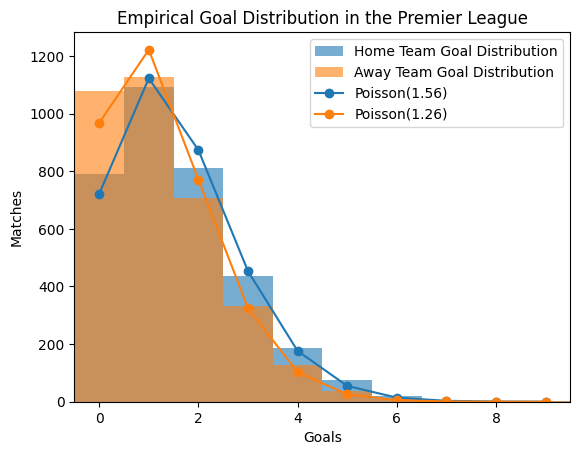

In [8]:
max_goals = int(max(matches["HomeGoals"].max(), matches["AwayGoals"].max()))
bins = [bin_edge - 0.5 for bin_edge in range(0, max_goals + 2)]
ks = np.arange(0, max_goals + 1)
n = len(matches)

home_team_average_goals = matches["HomeGoals"].mean()
away_team_average_goals = matches["AwayGoals"].mean()

fig, ax = plt.subplots()
ax.hist(matches["HomeGoals"], bins = bins, alpha = 0.6, label = "Home Team Goal Distribution")
ax.hist(matches["AwayGoals"], bins = bins, alpha = 0.6, label = "Away Team Goal Distribution")
ax.plot(ks, poisson_counts(home_team_average_goals, ks, n), "o-", color = "C0", label = f"Poisson({home_team_average_goals:.2f})")
ax.plot(ks, poisson_counts(away_team_average_goals, ks, n), "o-", color = "C1", label = f"Poisson({away_team_average_goals:.2f})")
ax.set_xlabel("Goals")
ax.set_ylabel("Matches")
ax.set_xlim(-0.5, 9.5)
ax.legend()
plt.title("Empirical Goal Distribution in the Premier League")
plt.show()